# BTC Return t-tests by Fear Status

This notebook uses `data/gold/btc_fng_with_holidays_api.csv` to test whether mean Bitcoin return differs when the market is in fear versus not in fear.

- `fear = True`: Fear or Extreme Fear
- `fear = False`: Neutral, Greed, or Extreme Greed

Tests included:
- One-sample t-test for mean return during fear vs 0
- One-sample t-test for mean return during non-fear vs 0
- Welch two-sample t-test comparing fear vs non-fear mean returns

In [1]:
import math
import numpy as np
import pandas as pd

In [2]:
path = r"data/gold/btc_fng_with_holidays_api.csv"
df = pd.read_csv(path)

df["fear"] = (
    df["fear"]
    .astype(str)
    .str.lower()
    .map({"true": True, "false": False})
)
df["btc_return_pct"] = pd.to_numeric(df["btc_return_pct"], errors="coerce")
df = df.dropna(subset=["btc_return_pct", "fear"]).copy()

fear_returns = df.loc[df["fear"], "btc_return_pct"].to_numpy(dtype=float)
non_fear_returns = df.loc[~df["fear"], "btc_return_pct"].to_numpy(dtype=float)

df[["date", "btc_return_pct", "fear", "fng_classification"]].head()

,date,btc_return_pct,fear,fng_classification
1,2025-04-03,0.008444,True,Extreme Fear
2,2025-04-04,0.008133,True,Fear
3,2025-04-05,-0.004195,True,Fear
4,2025-04-06,-0.061146,True,Fear
5,2025-04-07,0.009349,True,Extreme Fear


In [3]:
def t_pdf(x, dfree):
    log_coeff = (
        math.lgamma((dfree + 1) / 2)
        - 0.5 * (math.log(dfree) + math.log(math.pi))
        - math.lgamma(dfree / 2)
    )
    log_val = log_coeff - ((dfree + 1) / 2) * math.log(1 + (x * x) / dfree)
    return math.exp(log_val)

def t_cdf_numeric(x, dfree):
    if x == 0:
        return 0.5

    sign = 1 if x > 0 else -1
    x = abs(x)

    grid_size = max(20000, int(x * 4000))
    grid = np.linspace(0, x, grid_size + 1)
    density = np.array([t_pdf(float(value), dfree) for value in grid])
    area = np.trapezoid(density, grid)
    cdf_positive = min(max(0.5 + area, 0.0), 1.0)

    return cdf_positive if sign > 0 else 1 - cdf_positive

def two_sided_p_value(t_stat, dfree):
    cdf = t_cdf_numeric(t_stat, dfree)
    return 2 * min(cdf, 1 - cdf)

def one_sample_t_test(sample, mu=0.0):
    n = len(sample)
    mean = sample.mean()
    std = sample.std(ddof=1)
    se = std / math.sqrt(n)
    t_stat = (mean - mu) / se
    dfree = n - 1
    p_value = two_sided_p_value(t_stat, dfree)
    return {
        "n": n,
        "mean_return": mean,
        "std_dev": std,
        "t_stat": t_stat,
        "df": dfree,
        "p_value": p_value,
    }

def welch_two_sample_t_test(sample_a, sample_b):
    n_a, n_b = len(sample_a), len(sample_b)
    mean_a, mean_b = sample_a.mean(), sample_b.mean()
    std_a, std_b = sample_a.std(ddof=1), sample_b.std(ddof=1)

    se_squared = (std_a ** 2 / n_a) + (std_b ** 2 / n_b)
    t_stat = (mean_a - mean_b) / math.sqrt(se_squared)
    dfree = (se_squared ** 2) / (
        ((std_a ** 2 / n_a) ** 2 / (n_a - 1)) + ((std_b ** 2 / n_b) ** 2 / (n_b - 1))
    )
    p_value = two_sided_p_value(t_stat, dfree)

    return {
        "n_fear": n_a,
        "n_non_fear": n_b,
        "mean_fear": mean_a,
        "mean_non_fear": mean_b,
        "difference": mean_a - mean_b,
        "t_stat": t_stat,
        "df": dfree,
        "p_value": p_value,
    }

In [4]:
fear_one_sample = one_sample_t_test(fear_returns, mu=0.0)
non_fear_one_sample = one_sample_t_test(non_fear_returns, mu=0.0)
two_sample = welch_two_sample_t_test(fear_returns, non_fear_returns)

summary = pd.DataFrame([
    {
        "test": "One-sample: fear mean return = 0",
        "n": fear_one_sample["n"],
        "mean_return": fear_one_sample["mean_return"],
        "t_stat": fear_one_sample["t_stat"],
        "df": fear_one_sample["df"],
        "p_value": fear_one_sample["p_value"],
    },
    {
        "test": "One-sample: non-fear mean return = 0",
        "n": non_fear_one_sample["n"],
        "mean_return": non_fear_one_sample["mean_return"],
        "t_stat": non_fear_one_sample["t_stat"],
        "df": non_fear_one_sample["df"],
        "p_value": non_fear_one_sample["p_value"],
    },
    {
        "test": "Welch two-sample: fear vs non-fear",
        "n": f"{two_sample['n_fear']} vs {two_sample['n_non_fear']}",
        "mean_return": two_sample["difference"],
        "t_stat": two_sample["t_stat"],
        "df": two_sample["df"],
        "p_value": two_sample["p_value"],
    },
])

summary

,test,n,mean_return,t_stat,df,p_value
0,One-sample: fear mean return = 0,197,-0.001466,-0.770421,196.000000,0.441978
1,One-sample: non-fear mean return = 0,167,0.001186,0.866654,166.000000,0.387383
2,Welch two-sample: fear vs non-fear,197 vs 167,-0.002652,-1.131416,342.810806,0.258671


In [5]:
alpha = 0.05

print("Group means")
print(f"Fear mean return:     {fear_returns.mean():.6f}")
print(f"Non-fear mean return: {non_fear_returns.mean():.6f}")
print()

print("One-sample t-test: fear mean return vs 0")
print(f"t = {fear_one_sample['t_stat']:.4f}, df = {fear_one_sample['df']}, p = {fear_one_sample['p_value']:.4f}")
print("Reject H0" if fear_one_sample["p_value"] < alpha else "Fail to reject H0")
print()

print("One-sample t-test: non-fear mean return vs 0")
print(f"t = {non_fear_one_sample['t_stat']:.4f}, df = {non_fear_one_sample['df']}, p = {non_fear_one_sample['p_value']:.4f}")
print("Reject H0" if non_fear_one_sample["p_value"] < alpha else "Fail to reject H0")
print()

print("Welch two-sample t-test: fear vs non-fear")
print(f"t = {two_sample['t_stat']:.4f}, df = {two_sample['df']:.2f}, p = {two_sample['p_value']:.4f}")
print("Reject H0" if two_sample["p_value"] < alpha else "Fail to reject H0")

Group means
Fear mean return:     -0.001466
Non-fear mean return: 0.001186

One-sample t-test: fear mean return vs 0
t = -0.7704, df = 196, p = 0.4420
Fail to reject H0

One-sample t-test: non-fear mean return vs 0
t = 0.8667, df = 166, p = 0.3874
Fail to reject H0

Welch two-sample t-test: fear vs non-fear
t = -1.1314, df = 342.81, p = 0.2587
Fail to reject H0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_three_ttest_distributions(fear_returns, non_fear_returns):
    """
    Plots three separate distribution charts for t-test groups:
    1) Fear group
    2) Non-Fear group
    3) Fear vs Non-Fear comparison
    """
    sns.set_style("whitegrid")
    
    # -----------------------------
    # 1) Fear group vs 0
    plt.figure(figsize=(8,4))
    sns.kdeplot(fear_returns, fill=True, color="red", alpha=0.4)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.title("Distribution of BTC Returns: Fear Days", fontsize=12)
    plt.xlabel("BTC Daily Return")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()
    
    # -----------------------------
    # 2) Non-Fear group vs 0
    plt.figure(figsize=(8,4))
    sns.kdeplot(non_fear_returns, fill=True, color="blue", alpha=0.4)
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.title("Distribution of BTC Returns: Non-Fear Days", fontsize=12)
    plt.xlabel("BTC Daily Return")
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()
    
    # -----------------------------
    # 3) Fear vs Non-Fear comparison
    df_plot = pd.concat([
        pd.DataFrame({"return": fear_returns, "group": "Fear"}),
        pd.DataFrame({"return": non_fear_returns, "group": "Non-Fear"})
    ])
    
    plt.figure(figsize=(10,5))
    sns.kdeplot(
        data=df_plot,
        x="return",
        hue="group",
        fill=True,
        common_norm=False,
        alpha=0.4,
        palette={"Fear": "red", "Non-Fear": "blue"}
    )
    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.title("Distribution of BTC Returns: Fear vs Non-Fear", fontsize=12)
    plt.xlabel("BTC Daily Return")
    plt.ylabel("Density")
    plt.legend(title="Group")
    plt.tight_layout()
    plt.show()

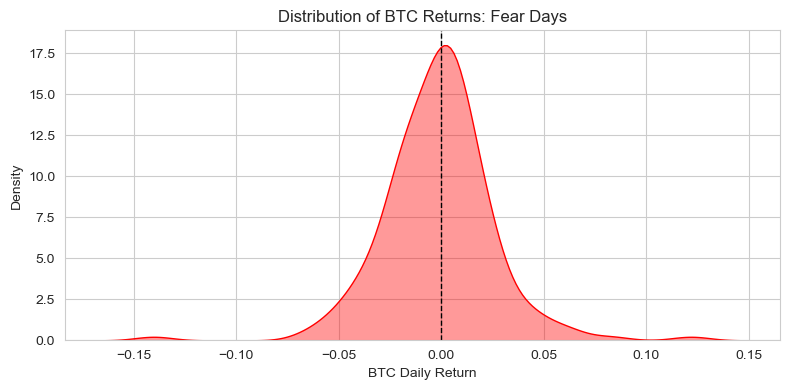

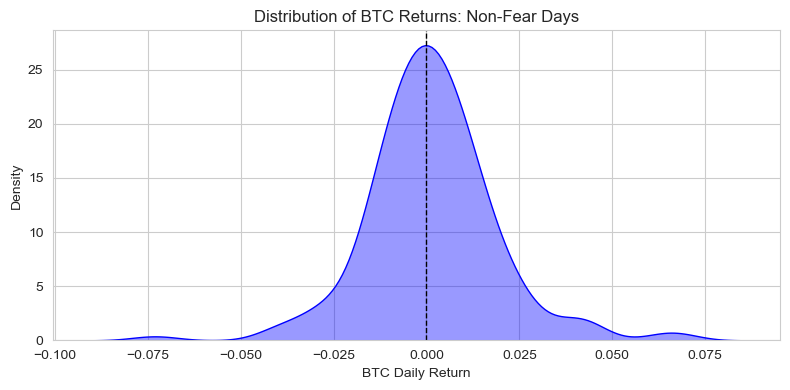

C:\Users\Christopher\AppData\Local\Temp\ipykernel_27524\3345149614.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Group")


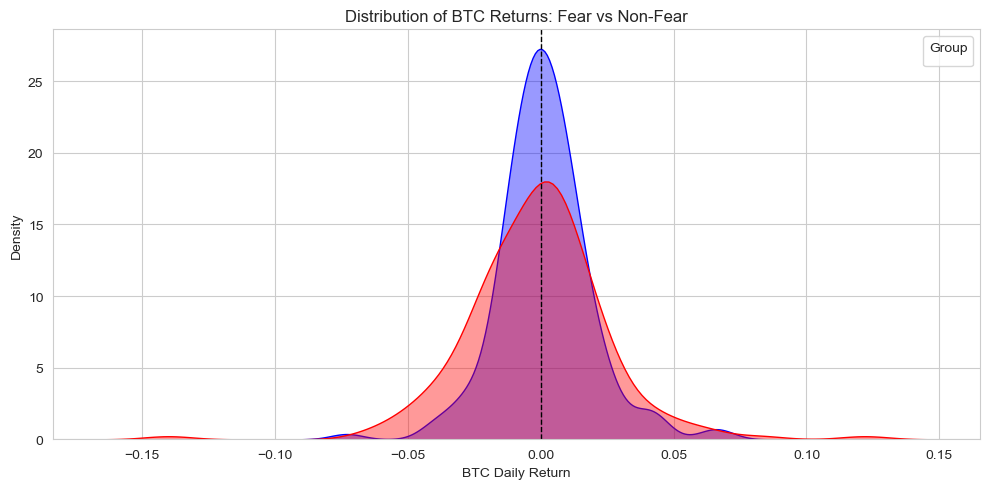

In [9]:
plot_three_ttest_distributions(fear_returns, non_fear_returns)